# VAYU — Data Preparation Pipeline
## Step 5: Clustering Dataset (K-Means)

**Prerequisite:** Steps 2–4 are independent. This step reads the 277 AQI Bulletin files directly — not the master cleaned file.

---

### What This Step Builds

**Model:** K-Means Clustering *(Lectures 55–56)*

**Goal:** Group 277 Indian cities into clusters based on their **pollution signature** — which cities have similar AQI patterns across seasons, how volatile their air quality is, and which pollutant dominates.

### Why Different Data Than Steps 3 and 4?

Steps 3 and 4 used `aqi_india_38cols_knn_final.csv` which has 29 cities. For clustering to be meaningful geographically — finding that northern plains cities cluster together, southern coastal cities cluster separately — we need as many cities as possible.

The 277 `*_AQIBulletins.csv` files each contain **daily AQI history for one city**, covering cities across every state in India. Stacked together they give us 277 city-level profiles — the richest geographic picture in our dataset.

### What K-Means Needs

| Requirement | Why |
|---|---|
| One row per city | K-Means clusters entities, not timesteps |
| All numeric features | Cannot work with text |
| No missing values | Distance computation breaks with NaN |
| StandardScaler normalized | K-Means is distance-based — a feature with range 0–500 dominates one with range 0–1 |
| No target column | Unsupervised — no labels used |

### Steps in This Notebook
1. Load and stack all 277 bulletin files
2. Aggregate to one row per city (city pollution profile)
3. Visualize city profiles and coverage
4. Normalize features with StandardScaler
5. Elbow method to find optimal K
6. Run K-Means with chosen K
7. Visualize clusters with PCA projection
8. Label and interpret clusters
9. Save clustering datasets

In [5]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 30)

DATA_ROOT  = './data'
OUTPUT_DIR = './data/cleaned/03_clustering'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Section 1 — Load and Stack All 277 Bulletin Files

### What Is in Each Bulletin File?

Each `*_AQIBulletins.csv` file contains the daily AQI history for one city:

```
date | City | No. Stations | Air Quality | Index Value | Prominent Pollutant
```

- `Index Value` = the numeric AQI for that day (0–500)
- `Air Quality` = the category label (Good / Moderate / etc.)
- `Prominent Pollutant` = which pollutant drove the AQI that day

These files have **no raw pollutant readings** — just the final AQI. That is why they cannot be used for regression or classification (no features). But for clustering city-level patterns, the AQI time series is exactly what we need.

In [6]:
bulletin_files = glob.glob(os.path.join(DATA_ROOT, '**/*AQIBulletins*.csv'), recursive=True)
print(f'Found {len(bulletin_files)} bulletin files')

if len(bulletin_files) == 0:
    raise FileNotFoundError(
        f'No AQI Bulletin files found in {DATA_ROOT}.\n'
        'These are the files named like "Delhi_AQIBulletins.csv".'
    )

dfs = []
failed = []

for fp in bulletin_files:
    try:
        tmp = pd.read_csv(fp, low_memory=False, encoding_errors='replace')
        # Standardize column names to lowercase
        tmp.columns = [c.strip().lower().replace(' ', '_') for c in tmp.columns]
        # Infer city from filename if column is missing
        if 'city' not in tmp.columns:
            tmp['city'] = os.path.basename(fp).replace('_AQIBulletins.csv', '')
        dfs.append(tmp)
    except Exception as e:
        failed.append((fp, str(e)))

if failed:
    print(f'Failed to read {len(failed)} files:')
    for fp, err in failed[:5]:
        print(f'  {os.path.basename(fp)}: {err}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nStacked shape  : {df_all.shape[0]:,} rows x {df_all.shape[1]} columns')
print(f'Columns        : {list(df_all.columns)}')
print(f'Unique cities  : {df_all["city"].nunique()}')
print(f'\nSample rows:')
display(df_all.head(3))

Found 277 bulletin files

Stacked shape  : 299,972 rows x 6 columns
Columns        : ['date', 'city', 'no._stations', 'air_quality', 'index_value', 'prominent_pollutant']
Unique cities  : 277

Sample rows:


,date,city,no._stations,air_quality,index_value,prominent_pollutant
0,2021-11-23,Chhapra,1.0,Very Poor,304,PM2.5
1,2021-11-24,Chhapra,1.0,Very Poor,319,PM2.5
2,2021-11-25,Chhapra,1.0,Very Poor,350,PM2.5


In [7]:
# ── Standardize column names ───────────────────────────────────────────────
# Different files may name the AQI column differently
col_map = {}
for col in df_all.columns:
    cl = col.lower()
    if   'index' in cl and 'value' in cl:  col_map[col] = 'aqi_value'
    elif cl == 'index_value':              col_map[col] = 'aqi_value'
    elif 'air_quality' in cl:              col_map[col] = 'aqi_category'
    elif 'prominent' in cl:               col_map[col] = 'prominent_pollutant'
    elif 'no._stations' in cl or 'no._of' in cl or 'num_stations' in cl:
                                           col_map[col] = 'num_stations'
    elif cl == 'date':                     col_map[col] = 'date'

df_all = df_all.rename(columns=col_map)
print('Column names after standardization:')
print(list(df_all.columns))

# Parse date and add temporal features
df_all['date']  = pd.to_datetime(df_all['date'], errors='coerce')
df_all['month'] = df_all['date'].dt.month
df_all['year']  = df_all['date'].dt.year
df_all['season'] = df_all['month'].map({
    12:'Winter',1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Monsoon',10:'Monsoon',11:'Monsoon'
})

# Convert AQI to numeric and cap at 500
df_all['aqi_value'] = pd.to_numeric(df_all['aqi_value'], errors='coerce')
df_all.loc[df_all['aqi_value'] > 500, 'aqi_value'] = np.nan
df_all.loc[df_all['aqi_value'] < 0,   'aqi_value'] = np.nan

print(f'\nDate range  : {df_all["date"].min().date()}  to  {df_all["date"].max().date()}')
print(f'AQI range   : {df_all["aqi_value"].min():.0f}  to  {df_all["aqi_value"].max():.0f}')
print(f'AQI NaN     : {df_all["aqi_value"].isna().sum():,}')

Column names after standardization:
['date', 'city', 'num_stations', 'aqi_category', 'aqi_value', 'prominent_pollutant']

Date range  : 2015-05-01  to  2023-12-31
AQI range   : 3  to  500
AQI NaN     : 0


---
## Section 2 — Build City-Level Feature Profiles

### Why Aggregate to One Row Per City?

K-Means clusters **entities**, not individual timesteps. We want to answer: "Which cities are similar to each other?" — not "Which days are similar?"

To do this, we collapse each city's entire history into a single row of summary statistics:

| Feature | What It Captures |
|---|---|
| `mean_aqi` | Overall pollution level |
| `std_aqi` | Volatility — does AQI swing wildly or stay stable? |
| `mean_aqi_winter` | Winter pollution (Nov–Feb) — stubble burning, cold air trapping |
| `mean_aqi_summer` | Summer pollution (Mar–May) — dust and heat |
| `mean_aqi_monsoon` | Monsoon pollution (Jun–Sep) — rain suppresses dust |
| `pct_poor_or_worse` | % of days with AQI > 200 — chronic bad air quality |
| `pct_pm25_dominant` | % of days PM2.5 was the prominent pollutant |
| `pct_pm10_dominant` | % of days PM10 was prominent |
| `pct_o3_dominant` | % of days O3 was prominent — southern/summer signature |

In [8]:
# Normalize city names
df_all['city'] = df_all['city'].astype(str).str.strip().str.title()

print('Building city profiles...')

# ── Core stats via groupby agg (no apply — avoids pandas 2.2 KeyError) ────
aqi_stats = df_all.groupby('city')['aqi_value'].agg(
    n_days   = 'count',
    mean_aqi = 'mean',
    median_aqi = 'median',
    std_aqi  = 'std',
    min_aqi  = 'min',
    max_aqi  = 'max',
).reset_index()

# % days poor or worse (AQI > 200) and severe (AQI > 400)
df_all['_poor']   = (df_all['aqi_value'] > 200).astype(float)
df_all['_severe'] = (df_all['aqi_value'] > 400).astype(float)
pct_stats = df_all.groupby('city')[['_poor','_severe']].mean().reset_index()
pct_stats = pct_stats.rename(columns={'_poor':'pct_poor_or_worse',
                                       '_severe':'pct_severe'})
pct_stats['pct_poor_or_worse'] *= 100
pct_stats['pct_severe']        *= 100
df_all.drop(columns=['_poor','_severe'], inplace=True)

# ── Seasonal means ─────────────────────────────────────────────────────────
seasonal_list = []
for season in ['Winter', 'Summer', 'Monsoon', 'Spring']:
    mask = df_all['season'] == season
    s = (df_all[mask]
         .groupby('city')['aqi_value']
         .mean()
         .rename(f'mean_aqi_{season.lower()}')
         .reset_index())
    seasonal_list.append(s)

from functools import reduce
seasonal_df = reduce(lambda l, r: pd.merge(l, r, on='city', how='outer'), seasonal_list)

# ── Prominent pollutant percentages ───────────────────────────────────────
if 'prominent_pollutant' in df_all.columns:
    pp = df_all[['city','prominent_pollutant']].copy()
    pp['pp_upper'] = pp['prominent_pollutant'].astype(str).str.strip().str.upper()

    total_pp = pp.groupby('city')['pp_upper'].count().rename('_total')

    def pp_pct(value_or_list, col_name):
        if isinstance(value_or_list, list):
            mask = pp['pp_upper'].isin(value_or_list)
        else:
            mask = pp['pp_upper'] == value_or_list
        return (pp[mask].groupby('city')['pp_upper'].count()
                        .div(total_pp).mul(100)
                        .rename(col_name)
                        .reset_index())

    pm25_df = pp_pct('PM2.5',        'pct_pm25_dominant')
    pm10_df = pp_pct('PM10',         'pct_pm10_dominant')
    o3_df   = pp_pct(['O3','OZONE'], 'pct_o3_dominant')
    no2_df  = pp_pct('NO2',          'pct_no2_dominant')

    pp_dfs = [pm25_df, pm10_df, o3_df, no2_df]
    pp_final = reduce(lambda l, r: pd.merge(l, r, on='city', how='outer'), pp_dfs)
else:
    pp_final = pd.DataFrame({'city': aqi_stats['city'].unique()})

# ── Merge everything ───────────────────────────────────────────────────────
city_profiles = aqi_stats.copy()
for extra in [pct_stats, seasonal_df, pp_final]:
    city_profiles = city_profiles.merge(extra, on='city', how='left')

city_profiles = city_profiles.dropna(subset=['city', 'mean_aqi'])

print(f'City profiles shape : {city_profiles.shape}')
print(f'Cities              : {len(city_profiles)}')
print(f'\nProfile columns:')
print(list(city_profiles.columns))
print()
display(city_profiles.head(5))

Building city profiles...
City profiles shape : (277, 17)
Cities              : 277

Profile columns:
['city', 'n_days', 'mean_aqi', 'median_aqi', 'std_aqi', 'min_aqi', 'max_aqi', 'pct_poor_or_worse', 'pct_severe', 'mean_aqi_winter', 'mean_aqi_summer', 'mean_aqi_monsoon', 'mean_aqi_spring', 'pct_pm25_dominant', 'pct_pm10_dominant', 'pct_o3_dominant', 'pct_no2_dominant']



,city,n_days,mean_aqi,median_aqi,std_aqi,min_aqi,max_aqi,pct_poor_or_worse,pct_severe,mean_aqi_winter,mean_aqi_summer,mean_aqi_monsoon,mean_aqi_spring,pct_pm25_dominant,pct_pm10_dominant,pct_o3_dominant,pct_no2_dominant
0,Agartala,1084,124.653137,99.5,83.571200,15.0,362.0,22.693727,0.000000,201.230241,51.729508,106.003584,127.292593,56.180812,24.630996,2.214022,NaN
1,Agra,2922,154.246407,118.0,107.528923,19.0,500.0,27.891855,2.943190,237.346591,77.115584,176.468421,130.989826,65.879535,9.069131,2.532512,1.608487
2,Ahmedabad,2538,134.108747,120.0,63.682079,15.0,500.0,14.381403,0.118203,159.767628,91.434251,143.183824,143.982759,39.519307,18.242711,8.865248,8.116627
3,Aizawl,1129,42.373782,28.0,31.822065,6.0,208.0,0.088574,0.000000,51.275362,23.892473,27.324000,62.317901,7.705934,66.696191,2.568645,NaN
4,Ajmer,2121,102.645922,97.0,37.153018,31.0,357.0,2.404526,0.000000,111.439623,85.678227,104.518248,108.599237,25.695427,63.743517,8.910891,0.188590


---
## Section 3 — Visualize City AQI Profiles

Before clustering, we visualize the data to get an intuition for the structure — how spread out are cities? Are there obvious groups? This helps us anticipate what K to choose.

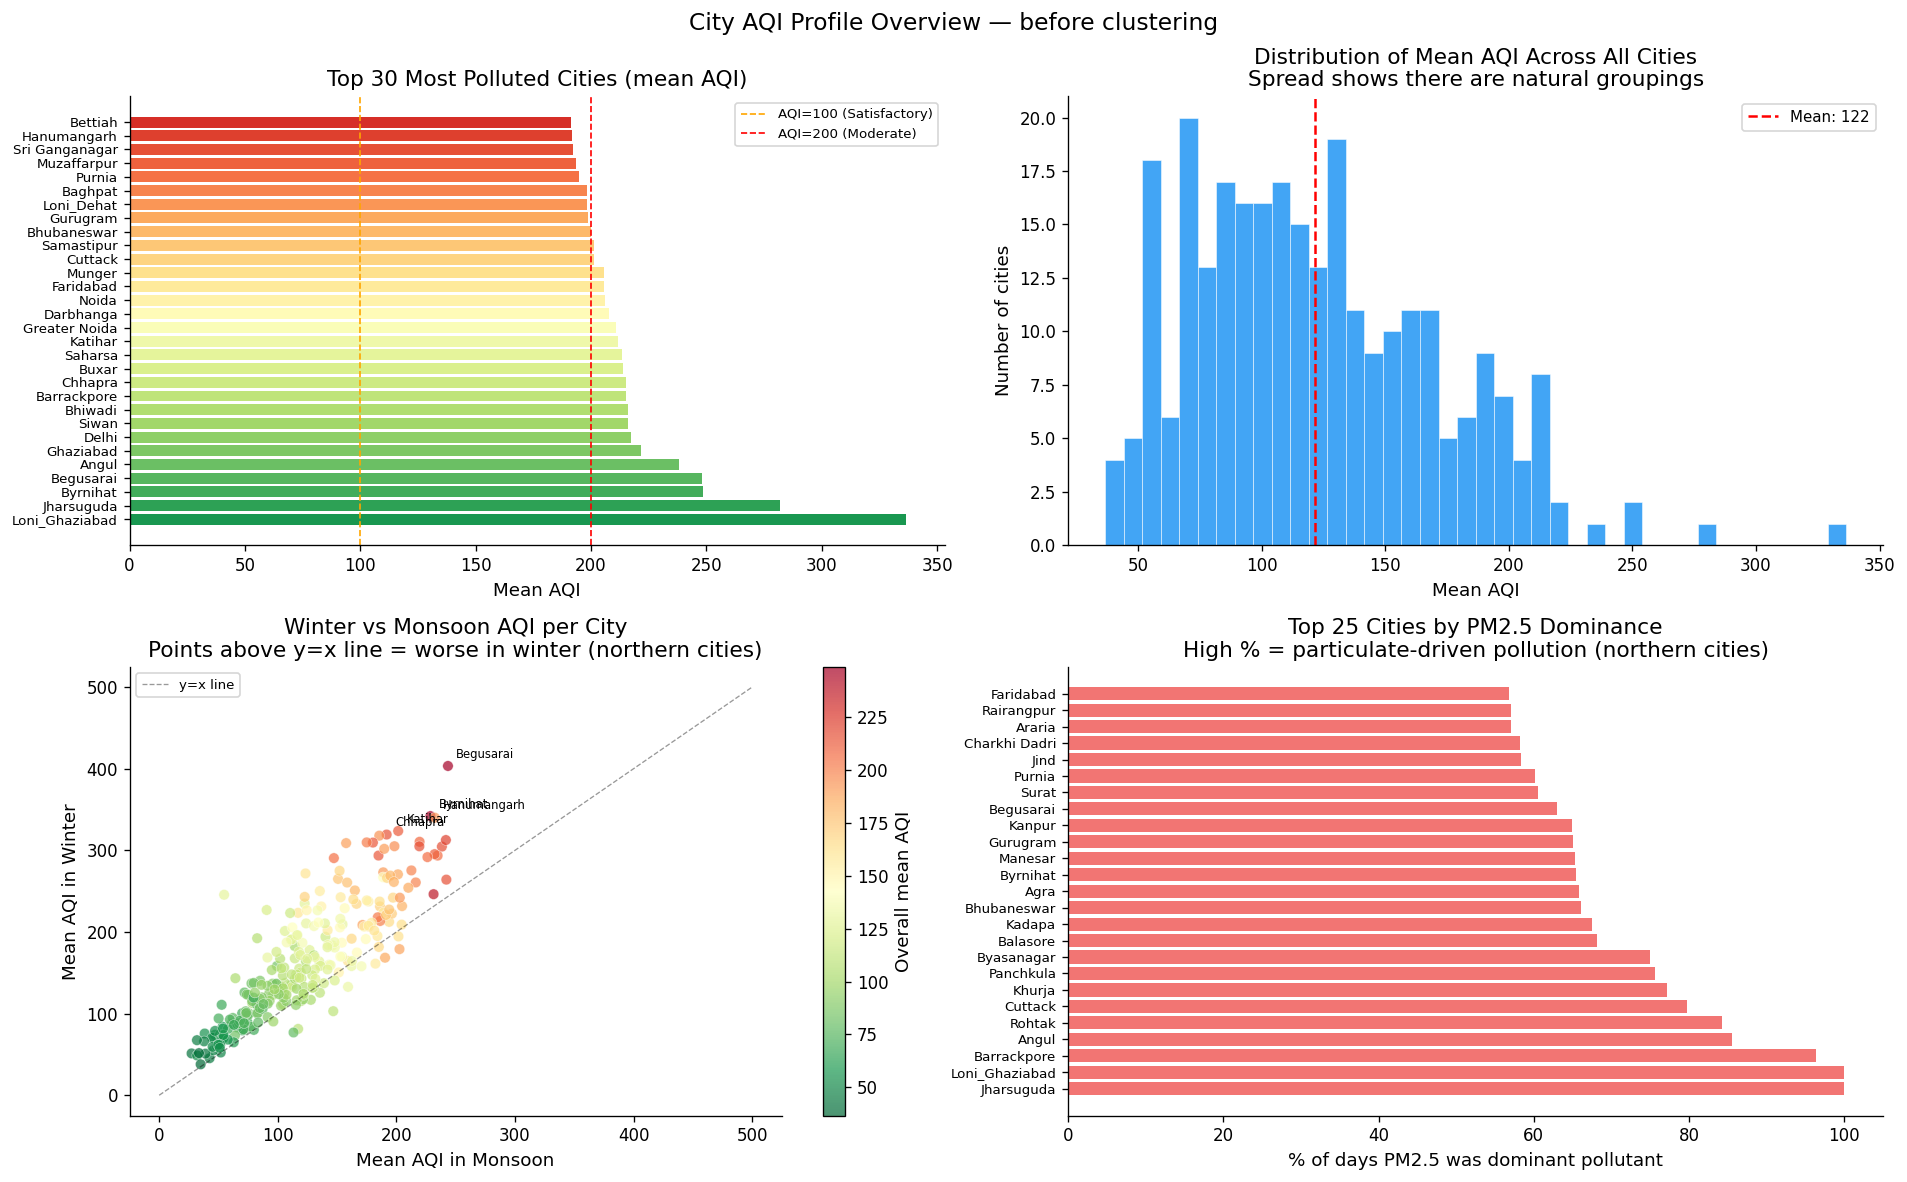

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Top 30 cities by mean AQI ─────────────────────────────────────────────
top30 = city_profiles.nlargest(30, 'mean_aqi')
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top30)))
axes[0][0].barh(top30['city'], top30['mean_aqi'], color=colors_bar)
axes[0][0].axvline(100, color='orange', linestyle='--', linewidth=1, label='AQI=100 (Satisfactory)')
axes[0][0].axvline(200, color='red',    linestyle='--', linewidth=1, label='AQI=200 (Moderate)')
axes[0][0].set_xlabel('Mean AQI')
axes[0][0].set_title('Top 30 Most Polluted Cities (mean AQI)')
axes[0][0].legend(fontsize=8)
axes[0][0].tick_params(axis='y', labelsize=8)

# ── AQI distribution across all cities ────────────────────────────────────
axes[0][1].hist(city_profiles['mean_aqi'].dropna(), bins=40,
                color='#42A5F5', edgecolor='white', linewidth=0.3)
axes[0][1].axvline(city_profiles['mean_aqi'].mean(), color='red',
                   linestyle='--', linewidth=1.5,
                   label=f'Mean: {city_profiles["mean_aqi"].mean():.0f}')
axes[0][1].set_xlabel('Mean AQI')
axes[0][1].set_ylabel('Number of cities')
axes[0][1].set_title('Distribution of Mean AQI Across All Cities\n'
                     'Spread shows there are natural groupings')
axes[0][1].legend(fontsize=9)

# ── Seasonal variation: Winter vs Monsoon ─────────────────────────────────
if 'mean_aqi_winter' in city_profiles.columns and 'mean_aqi_monsoon' in city_profiles.columns:
    scatter_df = city_profiles.dropna(subset=['mean_aqi_winter', 'mean_aqi_monsoon'])
    sc = axes[1][0].scatter(
        scatter_df['mean_aqi_monsoon'],
        scatter_df['mean_aqi_winter'],
        c=scatter_df['mean_aqi'],
        cmap='RdYlGn_r', alpha=0.7, s=40, edgecolors='white', linewidth=0.3
    )
    plt.colorbar(sc, ax=axes[1][0], label='Overall mean AQI')
    axes[1][0].plot([0,500],[0,500], 'k--', linewidth=0.8, alpha=0.4, label='y=x line')
    axes[1][0].set_xlabel('Mean AQI in Monsoon')
    axes[1][0].set_ylabel('Mean AQI in Winter')
    axes[1][0].set_title('Winter vs Monsoon AQI per City\n'
                         'Points above y=x line = worse in winter (northern cities)')
    axes[1][0].legend(fontsize=8)

    # Label the top 5 most extreme cities
    top5 = scatter_df.nlargest(5, 'mean_aqi_winter')
    for _, row in top5.iterrows():
        axes[1][0].annotate(row['city'],
                            (row['mean_aqi_monsoon'], row['mean_aqi_winter']),
                            fontsize=7, xytext=(5, 5), textcoords='offset points')

# ── % days PM2.5 dominant ─────────────────────────────────────────────────
if 'pct_pm25_dominant' in city_profiles.columns:
    pm25_data = city_profiles.sort_values('pct_pm25_dominant', ascending=False).head(25)
    axes[1][1].barh(pm25_data['city'], pm25_data['pct_pm25_dominant'],
                    color='#EF5350', alpha=0.8)
    axes[1][1].set_xlabel('% of days PM2.5 was dominant pollutant')
    axes[1][1].set_title('Top 25 Cities by PM2.5 Dominance\n'
                         'High % = particulate-driven pollution (northern cities)')
    axes[1][1].tick_params(axis='y', labelsize=8)

plt.suptitle('City AQI Profile Overview — before clustering', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 4 — Select Features and Normalize

### Which Features We Use and Why

We select features that capture different aspects of a city's pollution signature. Using only `mean_aqi` would group cities by overall pollution level — but we want richer clusters that also reflect **seasonal patterns** and **pollutant type**.

### Why StandardScaler Is Mandatory for K-Means

K-Means computes Euclidean distance between city feature vectors. Without scaling:
- `mean_aqi` ranges 0–500
- `pct_pm25_dominant` ranges 0–100
- `std_aqi` ranges 0–150

The feature with the largest absolute range (`mean_aqi`) would completely dominate the distance calculation. A city with mean_aqi=300 would always cluster with cities near mean_aqi=300 regardless of their seasonal pattern or pollutant type.

StandardScaler converts each feature to mean=0, std=1 — making all features contribute equally.

In [10]:
# Define clustering features
CLUSTER_FEATURES_CANDIDATES = [
    'mean_aqi',
    'std_aqi',
    'mean_aqi_winter',
    'mean_aqi_summer',
    'mean_aqi_monsoon',
    'pct_poor_or_worse',
    'pct_pm25_dominant',
    'pct_pm10_dominant',
    'pct_o3_dominant',
]

# Only keep features that exist and are not all-NaN
CLUSTER_FEATURES = [
    f for f in CLUSTER_FEATURES_CANDIDATES
    if f in city_profiles.columns and city_profiles[f].notna().sum() > 0
]

print(f'Clustering features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

# Drop cities with NaN in any clustering feature
df_cluster = city_profiles[['city'] + CLUSTER_FEATURES].dropna().reset_index(drop=True)
print(f'\nCities with complete profiles: {len(df_cluster)} / {len(city_profiles)}')

if len(df_cluster) < 10:
    raise ValueError(
        f'Only {len(df_cluster)} cities have complete profiles — too few for clustering.\n'
        'Check for NaN in the feature columns above.'
    )

# Normalize
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[CLUSTER_FEATURES])

print('\nPre-scaling statistics:')
print(df_cluster[CLUSTER_FEATURES].describe().round(1).to_string())

print('\nPost-scaling (mean should be ~0, std should be ~1):')
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
print(scaled_df.describe().round(3).to_string())

Clustering features (9): ['mean_aqi', 'std_aqi', 'mean_aqi_winter', 'mean_aqi_summer', 'mean_aqi_monsoon', 'pct_poor_or_worse', 'pct_pm25_dominant', 'pct_pm10_dominant', 'pct_o3_dominant']

Cities with complete profiles: 229 / 277

Pre-scaling statistics:
       mean_aqi  std_aqi  mean_aqi_winter  mean_aqi_summer  mean_aqi_monsoon  pct_poor_or_worse  pct_pm25_dominant  pct_pm10_dominant  pct_o3_dominant
count     229.0    229.0            229.0            229.0             229.0              229.0              229.0              229.0            229.0
mean      120.7     64.6            165.7             76.5             123.5               15.8               27.7               47.1              9.4
std        45.3     26.4             70.3             27.1              50.6               15.5               16.6               20.4             10.7
min        38.3     13.2             45.4             23.9              27.3                0.0                1.1                1.8       

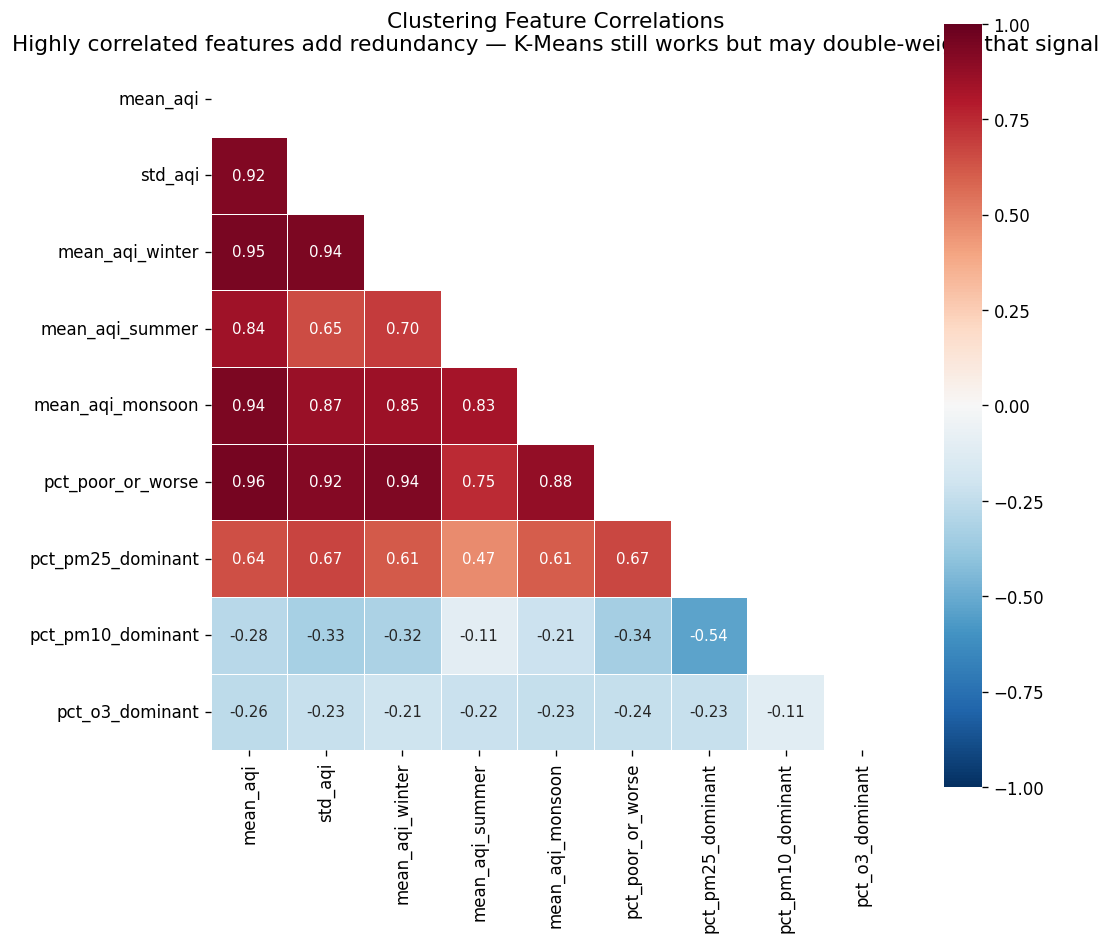

In [11]:
# ── Feature correlation heatmap ────────────────────────────────────────────
corr_mat = df_cluster[CLUSTER_FEATURES].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax  = plt.subplots(figsize=(max(8, len(CLUSTER_FEATURES)), max(6, len(CLUSTER_FEATURES)-1)))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Clustering Feature Correlations\n'
             'Highly correlated features add redundancy — K-Means still works but may double-weight that signal')
plt.tight_layout()
plt.show()

---
## Section 5 — Elbow Method to Find Optimal K

### How Do We Choose K?

K-Means requires you to specify the number of clusters in advance. The **Elbow Method** helps by plotting the **inertia** (sum of squared distances from each point to its cluster center) against K.

- As K increases, inertia always decreases — more clusters means points are closer to their center
- The optimal K is where the curve bends like an elbow — the point where adding another cluster gives diminishing returns

We also compute the **Silhouette Score** for each K — this measures how similar each city is to its own cluster vs neighbouring clusters. Score ranges from -1 to 1. Higher is better. The K with the highest silhouette score is the most interpretable clustering.

Running K-Means for K = 2 to 12 ...
  K= 2  inertia=    1102.7  silhouette=0.3780
  K= 3  inertia=     859.4  silhouette=0.2816
  K= 4  inertia=     754.7  silhouette=0.2577
  K= 5  inertia=     677.9  silhouette=0.2196
  K= 6  inertia=     616.3  silhouette=0.2287
  K= 7  inertia=     567.8  silhouette=0.2234
  K= 8  inertia=     531.4  silhouette=0.2075
  K= 9  inertia=     488.6  silhouette=0.2232
  K=10  inertia=     463.0  silhouette=0.2120
  K=11  inertia=     441.9  silhouette=0.2016
  K=12  inertia=     421.3  silhouette=0.2102

Elbow method suggests K = 3
Best silhouette score at K = 2  (score=0.3780)


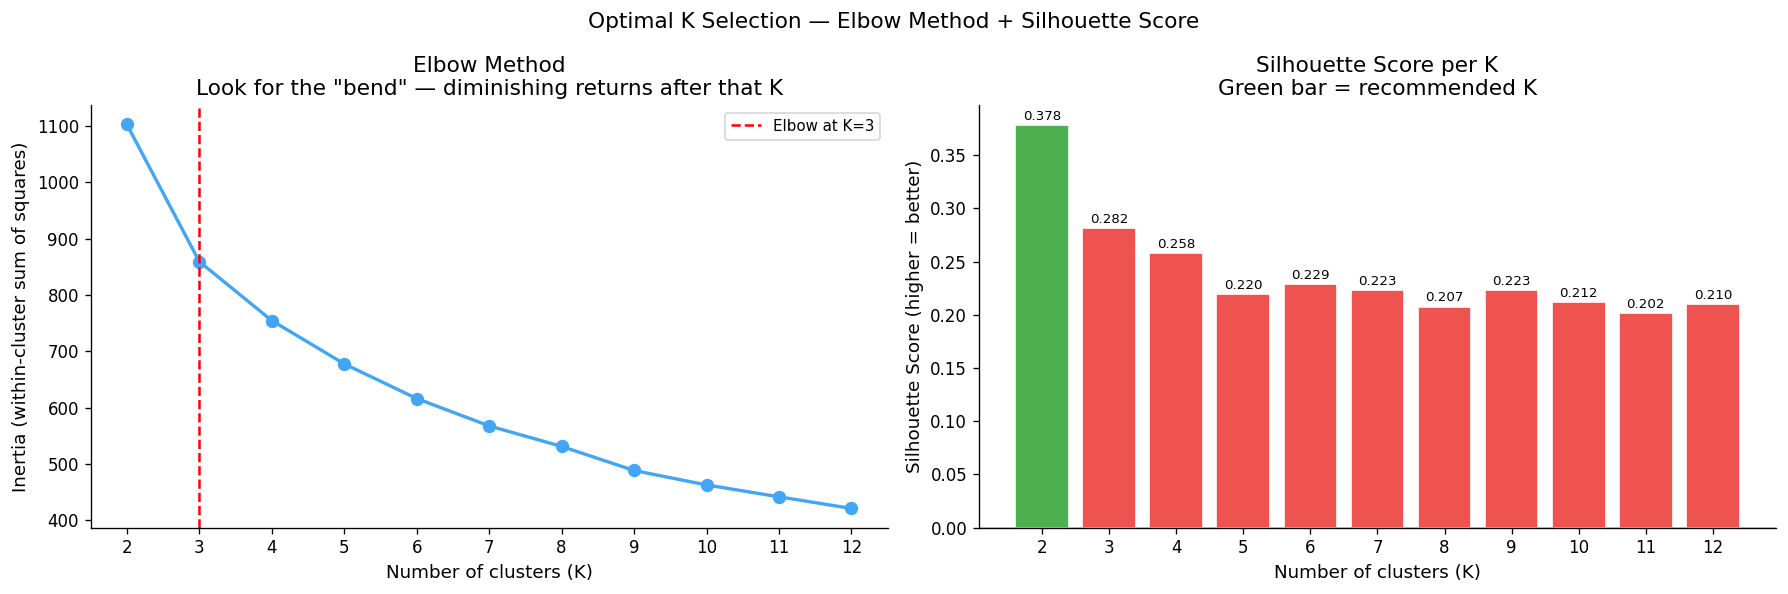


Recommended: Use K=2 (best silhouette score)
Or use K=3 (elbow method) if you prefer fewer, broader clusters


In [12]:
max_k       = min(12, len(df_cluster) - 1)
k_range     = range(2, max_k + 1)
inertias    = []
silhouettes = []

print('Running K-Means for K = 2 to', max_k, '...')
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl)
    silhouettes.append(sil)
    print(f'  K={k:>2}  inertia={km.inertia_:>10.1f}  silhouette={sil:.4f}')

# Find elbow using rate of change
inertia_changes = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
elbow_idx       = np.argmin(np.diff(inertia_changes)) + 1 if len(inertia_changes) > 1 else 0
elbow_k         = list(k_range)[elbow_idx]
best_sil_k      = list(k_range)[np.argmax(silhouettes)]

print(f'\nElbow method suggests K = {elbow_k}')
print(f'Best silhouette score at K = {best_sil_k}  (score={max(silhouettes):.4f})')

# ── Elbow + Silhouette plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Inertia (elbow)
axes[0].plot(list(k_range), inertias, 'o-', color='#42A5F5', linewidth=2, markersize=7)
axes[0].axvline(elbow_k, color='red', linestyle='--', linewidth=1.5,
                label=f'Elbow at K={elbow_k}')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method\nLook for the "bend" — diminishing returns after that K')
axes[0].legend(fontsize=9)
axes[0].set_xticks(list(k_range))

# Silhouette scores
bar_colors = ['#EF5350' if k != best_sil_k else '#4CAF50' for k in k_range]
axes[1].bar(list(k_range), silhouettes, color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Silhouette Score per K\nGreen bar = recommended K')
axes[1].set_xticks(list(k_range))
for i, (k, s) in enumerate(zip(k_range, silhouettes)):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=8)

plt.suptitle('Optimal K Selection — Elbow Method + Silhouette Score', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nRecommended: Use K={best_sil_k} (best silhouette score)')
print(f'Or use K={elbow_k} (elbow method) if you prefer fewer, broader clusters')

---
## Section 6 — Run K-Means with Chosen K

We use the K suggested by the silhouette score. You can override this by changing `CHOSEN_K` below.

In [13]:
# ── Set K — change this if you want a different number of clusters ─────────
CHOSEN_K = best_sil_k   # or: CHOSEN_K = elbow_k  or any integer
# ───────────────────────────────────────────────────────────────────────────

print(f'Running K-Means with K={CHOSEN_K}...')
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20)
labels   = km_final.fit_predict(X_scaled)

df_cluster['cluster'] = labels

final_sil = silhouette_score(X_scaled, labels)
print(f'Final silhouette score : {final_sil:.4f}')
print(f'Inertia                : {km_final.inertia_:.1f}')
print()
print('Cities per cluster:')
for c, count in sorted(df_cluster['cluster'].value_counts().items()):
    cities_in_cluster = df_cluster[df_cluster['cluster'] == c]['city'].tolist()
    preview = ', '.join(cities_in_cluster[:5])
    if len(cities_in_cluster) > 5:
        preview += f' ... (+{len(cities_in_cluster)-5} more)'
    print(f'  Cluster {c}: {count:>3} cities — {preview}')

Running K-Means with K=2...
Final silhouette score : 0.3780
Inertia                : 1102.7

Cities per cluster:
  Cluster 0: 131 cities — Aizawl, Ajmer, Akola, Alwar, Amaravati ... (+126 more)
  Cluster 1:  98 cities — Agartala, Agra, Ahmedabad, Ambala, Ankleshwar ... (+93 more)


Mean feature values per cluster:


,mean_aqi,std_aqi,mean_aqi_winter,mean_aqi_summer,mean_aqi_monsoon,pct_poor_or_worse,pct_pm25_dominant,pct_pm10_dominant,pct_o3_dominant
cluster,,,,,,,,,
0,89.3,46.3,117.3,61.0,90.7,4.8,18.3,53.1,11.0
1,162.8,89.0,230.3,97.2,167.4,30.5,40.1,39.0,7.3


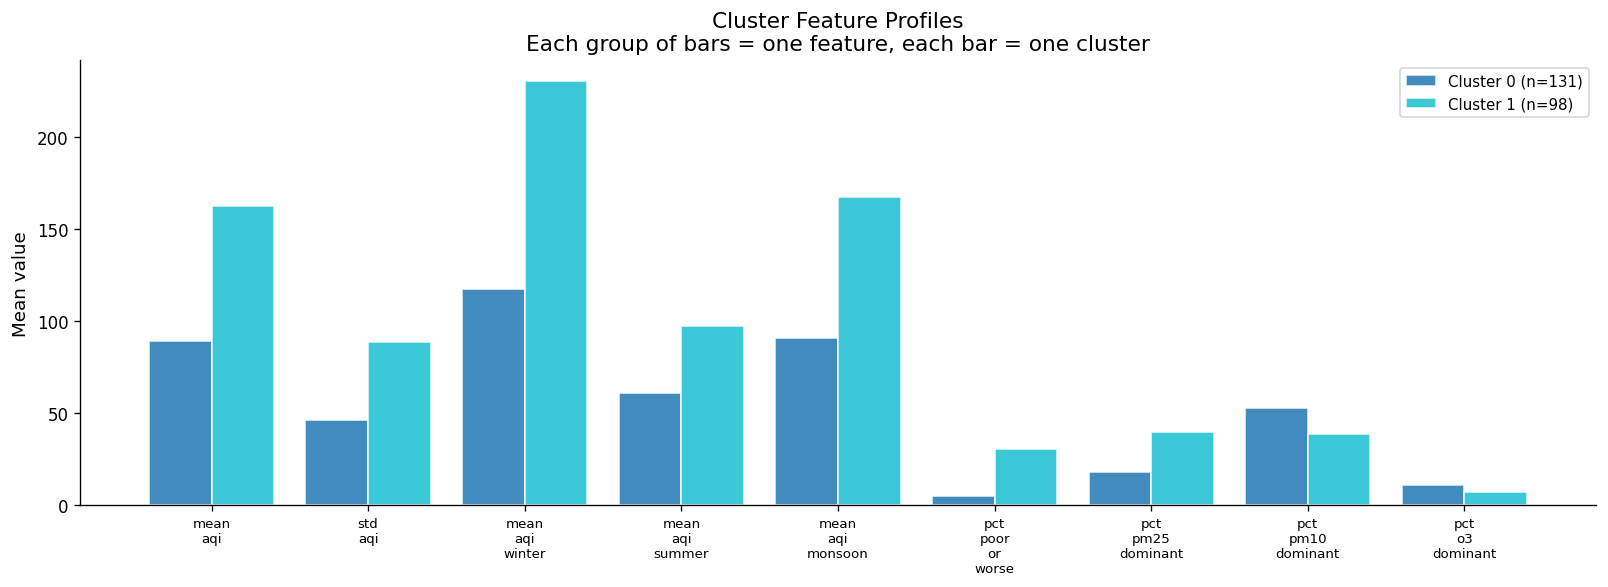

In [14]:
# ── Cluster profiles — mean of each feature per cluster ───────────────────
cluster_profiles = df_cluster.groupby('cluster')[CLUSTER_FEATURES].mean().round(1)

print('Mean feature values per cluster:')
display(cluster_profiles)

fig, ax = plt.subplots(figsize=(max(12, len(CLUSTER_FEATURES)*1.5), 5))

cluster_colors = plt.cm.tab10(np.linspace(0, 0.9, CHOSEN_K))
x = np.arange(len(CLUSTER_FEATURES))
width = 0.8 / CHOSEN_K

for i, (cluster_id, row) in enumerate(cluster_profiles.iterrows()):
    offset = (i - CHOSEN_K/2 + 0.5) * width
    n_cities = (df_cluster['cluster'] == cluster_id).sum()
    ax.bar(x + offset, row.values, width, label=f'Cluster {cluster_id} (n={n_cities})',
           color=cluster_colors[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_', '\n') for f in CLUSTER_FEATURES], fontsize=8)
ax.set_ylabel('Mean value')
ax.set_title('Cluster Feature Profiles\n'
             'Each group of bars = one feature, each bar = one cluster')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

---
## Section 7 — Visualize Clusters with PCA Projection

### Why Use PCA to Visualize?

Our city profiles have multiple features — we cannot directly plot them in 2D. PCA reduces these features to 2 principal components that capture the most variance, allowing us to plot all cities on a 2D scatter and see whether the clusters are well-separated.

Well-separated clusters = K-Means found genuine structure in the data.  
Overlapping clusters = either K is wrong or the features don't capture the relevant differences.

PCA explained variance: PC1=66.6%  PC2=13.4%  Total=80.0%


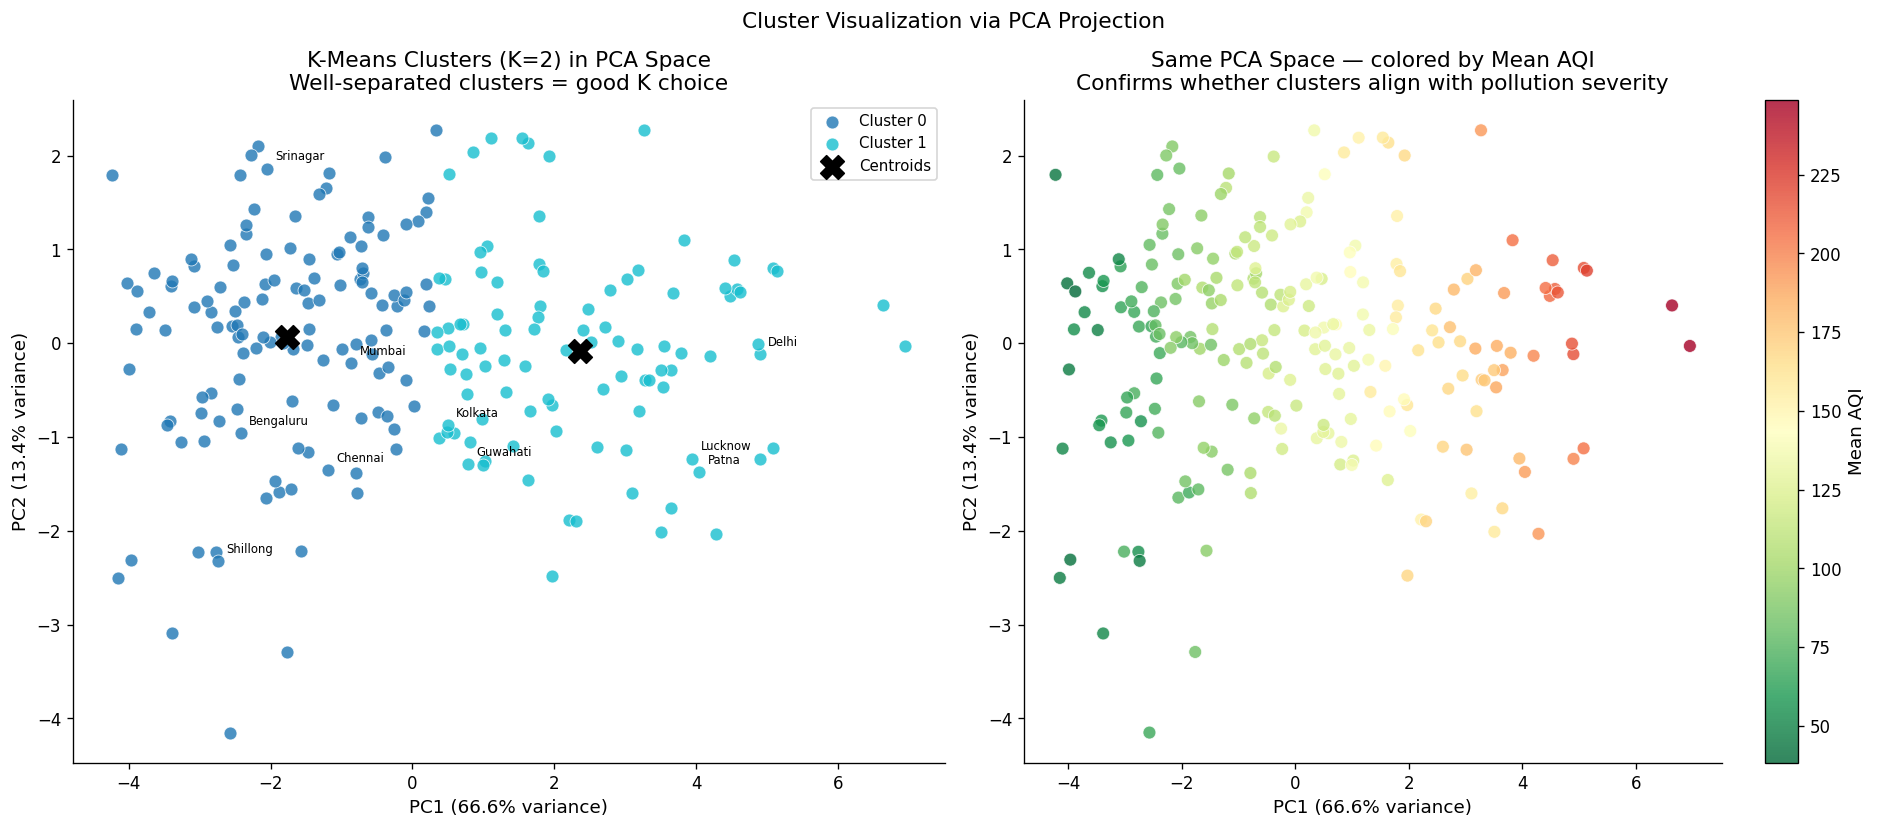

In [15]:
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_

df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]

print(f'PCA explained variance: PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%  Total={sum(var_exp)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cluster_colors = plt.cm.tab10(np.linspace(0, 0.9, CHOSEN_K))

# Left: scatter colored by cluster
for cluster_id in range(CHOSEN_K):
    mask = df_cluster['cluster'] == cluster_id
    axes[0].scatter(
        df_cluster.loc[mask, 'pca1'],
        df_cluster.loc[mask, 'pca2'],
        color=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        s=60, alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Plot cluster centroids in PCA space
centers_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                marker='X', s=200, color='black', zorder=5, label='Centroids')

# Label a few notable cities
notable = ['Delhi', 'Mumbai', 'Bengaluru', 'Chennai', 'Kolkata',
           'Patna', 'Lucknow', 'Guwahati', 'Srinagar', 'Shillong']
for _, row in df_cluster[df_cluster['city'].isin(notable)].iterrows():
    axes[0].annotate(row['city'], (row['pca1'], row['pca2']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[0].set_title(f'K-Means Clusters (K={CHOSEN_K}) in PCA Space\nWell-separated clusters = good K choice')
axes[0].legend(fontsize=9)

# Right: scatter colored by mean AQI
sc = axes[1].scatter(
    df_cluster['pca1'], df_cluster['pca2'],
    c=df_cluster['mean_aqi'], cmap='RdYlGn_r',
    s=60, alpha=0.8, edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=axes[1], label='Mean AQI')
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[1].set_title('Same PCA Space — colored by Mean AQI\nConfirms whether clusters align with pollution severity')

plt.suptitle('Cluster Visualization via PCA Projection', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 8 — Interpret and Label Clusters

After seeing the cluster profiles, we assign descriptive labels based on what the data shows. These are interpretive — adjust the labels to match what you see in the profile chart above.

Cluster labels (auto-assigned by mean AQI rank):

  Cluster 0 — "Relatively Clean"  (mean AQI = 89)
  Cities: ['Aizawl', 'Ajmer', 'Akola', 'Alwar', 'Amaravati', 'Amravati']

  Cluster 1 — "Heavily Polluted"  (mean AQI = 163)
  Cities: ['Agartala', 'Agra', 'Ahmedabad', 'Ambala', 'Ankleshwar', 'Araria']


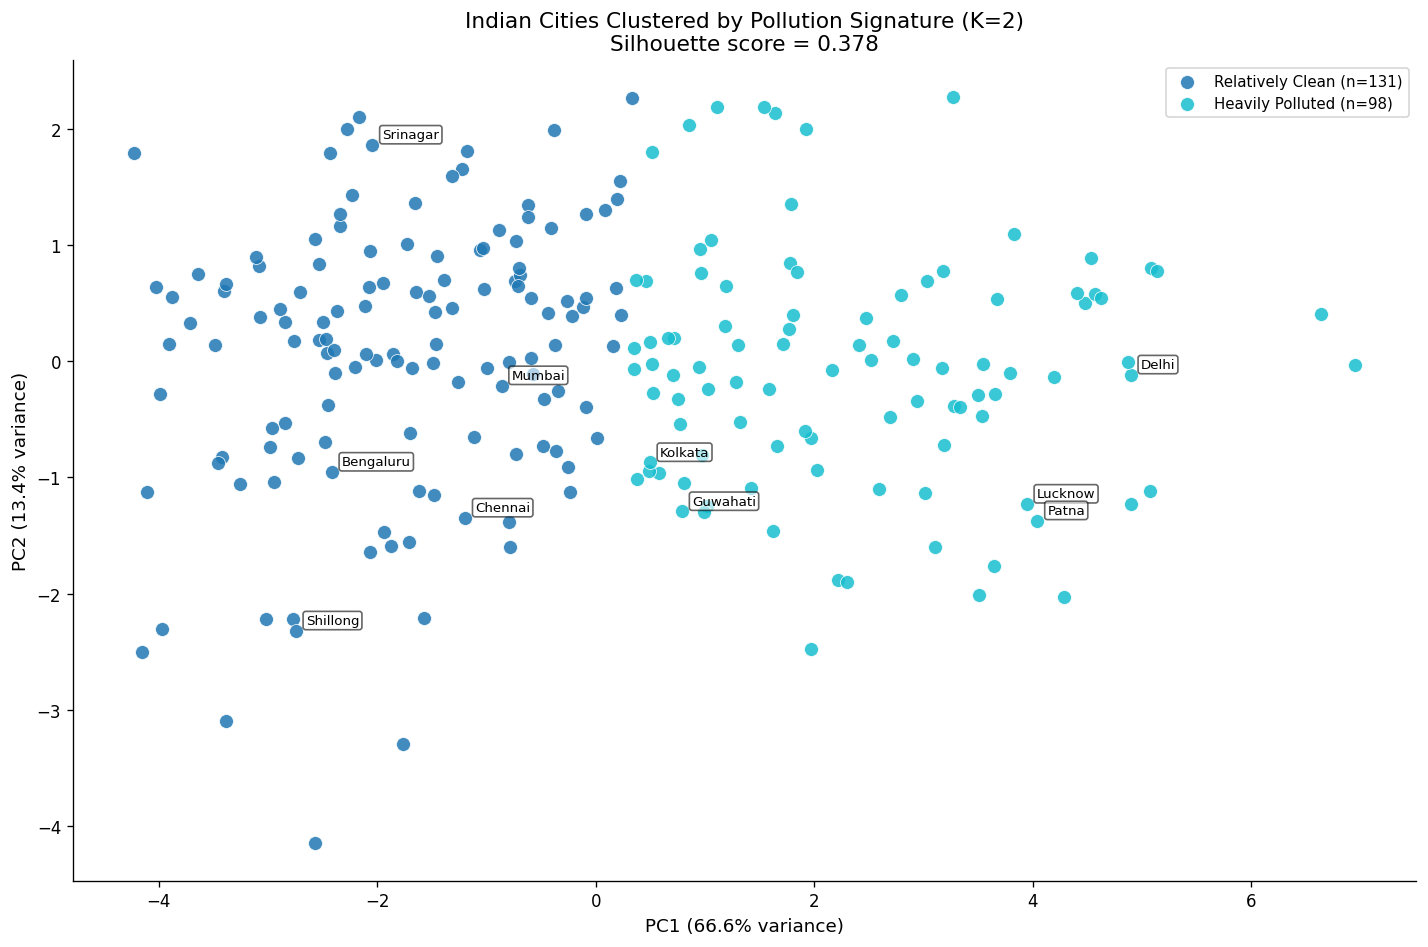

In [16]:
# Auto-label clusters based on mean_aqi quartiles
cluster_mean_aqi = df_cluster.groupby('cluster')['mean_aqi'].mean().sort_values()

n = len(cluster_mean_aqi)
auto_labels = {}
if n == 2:
    labels_map = ['Relatively Clean', 'Heavily Polluted']
elif n == 3:
    labels_map = ['Relatively Clean', 'Moderate Pollution', 'Heavily Polluted']
elif n == 4:
    labels_map = ['Clean (Southern/Hill)', 'Moderate Urban', 'Industrial/Northern', 'Severe Pollution']
else:
    labels_map = [f'Cluster {i} (AQI~{v:.0f})' for i, v in enumerate(sorted(cluster_mean_aqi.values))]

for (cluster_id, _), label in zip(cluster_mean_aqi.items(), labels_map):
    auto_labels[cluster_id] = label

df_cluster['cluster_label'] = df_cluster['cluster'].map(auto_labels)

print('Cluster labels (auto-assigned by mean AQI rank):')
for c_id, label in auto_labels.items():
    mean_aqi_val = cluster_mean_aqi[c_id]
    cities_preview = df_cluster[df_cluster['cluster'] == c_id]['city'].tolist()[:6]
    print(f'\n  Cluster {c_id} — "{label}"  (mean AQI = {mean_aqi_val:.0f})')
    print(f'  Cities: {cities_preview}')

# ── Final labeled scatter ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(CHOSEN_K):
    mask  = df_cluster['cluster'] == cluster_id
    label = auto_labels.get(cluster_id, f'Cluster {cluster_id}')
    ax.scatter(
        df_cluster.loc[mask, 'pca1'],
        df_cluster.loc[mask, 'pca2'],
        color=cluster_colors[cluster_id],
        label=f'{label} (n={mask.sum()})',
        s=70, alpha=0.85, edgecolors='white', linewidth=0.5
    )

# Label notable cities
for _, row in df_cluster[df_cluster['city'].isin(notable)].iterrows():
    ax.annotate(row['city'], (row['pca1'], row['pca2']),
                fontsize=8, xytext=(6, 4), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
ax.set_title(f'Indian Cities Clustered by Pollution Signature (K={CHOSEN_K})\n'
             f'Silhouette score = {final_sil:.3f}')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

---
## Section 9 — Save Clustering Datasets

In [17]:
PROFILES_PATH = os.path.join(OUTPUT_DIR, 'city_profiles.csv')
CLUSTERS_PATH = os.path.join(OUTPUT_DIR, 'city_clusters.csv')
SCALED_PATH   = os.path.join(OUTPUT_DIR, 'city_profiles_scaled.csv')
STACKED_PATH  = os.path.join(OUTPUT_DIR, 'bulletins_stacked.csv')

# City profiles (unscaled — readable)
city_profiles.to_csv(PROFILES_PATH, index=False)

# City profiles with cluster assignments
df_cluster.to_csv(CLUSTERS_PATH, index=False)

# Scaled feature matrix
scaled_out = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
scaled_out.insert(0, 'city', df_cluster['city'].values)
scaled_out['cluster']       = df_cluster['cluster'].values
scaled_out['cluster_label'] = df_cluster['cluster_label'].values
scaled_out.to_csv(SCALED_PATH, index=False)

# Full stacked bulletins (for time-series analysis in Eval 2)
df_all.to_csv(STACKED_PATH, index=False)

print('SAVED:')
for path in [PROFILES_PATH, CLUSTERS_PATH, SCALED_PATH, STACKED_PATH]:
    mb = os.path.getsize(path) / 1024**2
    print(f'  {os.path.basename(path):<35} {mb:.1f} MB')

print()
print('=' * 60)
print('  STEP 5 COMPLETE')
print('=' * 60)
print(f'  Cities profiled      : {len(city_profiles)}')
print(f'  Cities clustered     : {len(df_cluster)}')
print(f'  K chosen             : {CHOSEN_K}')
print(f'  Silhouette score     : {final_sil:.4f}')
print(f'  Features used        : {CLUSTER_FEATURES}')
print()
print('  TO USE IN KMEANS MODEL:')
print('  profiles = pd.read_csv("data/cleaned/03_clustering/city_profiles_scaled.csv")')
print('  X = profiles[feature_list].values')
print('  km = KMeans(n_clusters=K).fit(X)')
print('='*60)

SAVED:
  city_profiles.csv                   0.1 MB
  city_clusters.csv                   0.0 MB
  city_profiles_scaled.csv            0.0 MB
  bulletins_stacked.csv               16.9 MB

  STEP 5 COMPLETE
  Cities profiled      : 277
  Cities clustered     : 229
  K chosen             : 2
  Silhouette score     : 0.3780
  Features used        : ['mean_aqi', 'std_aqi', 'mean_aqi_winter', 'mean_aqi_summer', 'mean_aqi_monsoon', 'pct_poor_or_worse', 'pct_pm25_dominant', 'pct_pm10_dominant', 'pct_o3_dominant']

  TO USE IN KMEANS MODEL:
  profiles = pd.read_csv("data/cleaned/03_clustering/city_profiles_scaled.csv")
  X = profiles[feature_list].values
  km = KMeans(n_clusters=K).fit(X)
